# Referencing the laser spot the sample

In this notebook, we cover extracting the size of the laser spot on our sample and overlaying it on our sample image. 

In [1]:
from leman.loaders import ACSampleImg, ACLaserRefImg
from pathlib import Path

We first find our image of the laser spot and preview it. The algorithm to find the laser spot works best if we image the spot in dark conditions (no white light / sample illumination). It's still possible to find the laser spot with a white light turned on, but it may be more difficult. One can tune the parameters `expected_radius_px` and `tophat_radius` (which is the radius of our white light spot on the sample) to find the laser spot if they are having trouble.

(<Figure size 640x480 with 1 Axes>, <Axes: >)

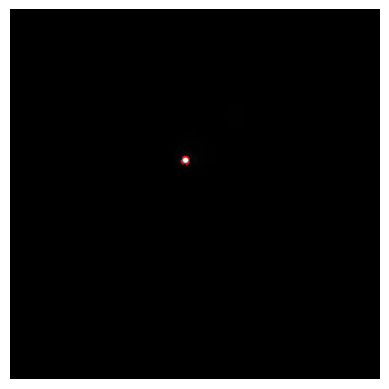

In [2]:
filepath = Path('./data/stark-shift')

laser_ref = ACLaserRefImg(
    path = sorted(filepath.glob("laser_*.csv"))[0],
    # expected_radius_px : float = 10.0,  ##### Additional parameters that can be applied.
    # white_light        : bool  = True,
    # tophat_radius      : float = None,
)

laser_ref.show_image(laser_annotation = True)

When we initialise `ACLaserRefImg`, it automatically calculates the laser spot size in pixels.

In [3]:
print(laser_ref)

ACLaserRefImg
  File                  : data\stark-shift\laser_26_05_15_14_04_45.csv
  Center                : (242.5, 208.8) px
  Estimated 1/e² Radius : 5.7 px
  Estimated 1/e² Diameter: 11.4 px


Now we load our sample image, but we pass our laser reference image as an argument. Then we can show our sample image with the laser spot annotation on it.

(<Figure size 640x480 with 1 Axes>, <Axes: >)

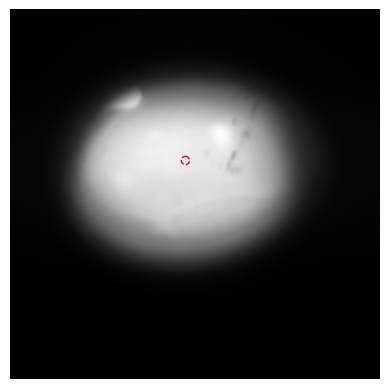

In [4]:
sample_img = ACSampleImg(
    path = sorted(filepath.glob("wl_*.csv"))[0],
    laser_ref = laser_ref
)

sample_img.show_image(laser_annotation = True)